In [67]:
import numpy as np
from matplotlib.patches import Polygon

def add_aci_dimension(
    ax,
    p1,
    p2,
    obj_center=(0, 0),
    offset=40,
    label=None,
    inches=False,
    arrow_length=16,
    arrow_width=5,
    ext_gap=6,
    ext_overhang=10,
    lw_dim=1.2,
    lw_ext=1.0,
    fontsize=12,
    scale="auto",
    alignment="auto",   # "auto", "horizontal", "vertical", "aligned"
):

    # ---------------------------------------------
    # Convert to arrays
    # ---------------------------------------------
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    obj_center = np.asarray(obj_center, dtype=float)

    edge = p2 - p1
    dx, dy = edge
    L = np.linalg.norm(edge)
    if L == 0:
        return

    # ---------------------------------------------
    # Alignment handling
    # ---------------------------------------------
    tol = 1e-9

    if alignment == "auto":
        if abs(dy) < tol:
            alignment = "horizontal"
        elif abs(dx) < tol:
            alignment = "vertical"
        else:
            alignment = "aligned"

    if alignment == "horizontal":
        # Project to horizontal
        p2 = np.array([p2[0], p1[1]])
        edge = p2 - p1
        L = abs(edge[0])
        unit = np.array([1.0, 0.0])
        normal = np.array([0.0, 1.0])

    elif alignment == "vertical":
        # Project to vertical
        p2 = np.array([p1[0], p2[1]])
        edge = p2 - p1
        L = abs(edge[1])
        unit = np.array([0.0, 1.0])
        normal = np.array([-1.0, 0.0])

    else:  # "aligned"
        unit = edge / L
        normal = np.array([-unit[1], unit[0]])

    # ---------------------------------------------
    # Scaling logic
    # ---------------------------------------------
    if scale == "auto":
        arrow_length = 0.04 * L
        arrow_width  = 0.012 * L
        ext_gap      = 0.01 * L
        ext_overhang = 0.02 * L
        text_offset  = 0.03 * L
    else:
        factor = float(scale)
        arrow_length *= factor
        arrow_width  *= factor
        ext_gap      *= factor
        ext_overhang *= factor
        text_offset  = 0.03 * L * factor

    # ---------------------------------------------
    # Ensure outside placement
    # ---------------------------------------------
    mid = (p1 + p2) / 2
    if np.linalg.norm(mid + normal - obj_center) < np.linalg.norm(mid - obj_center):
        normal *= -1

    # ---------------------------------------------
    # Dimension line points
    # ---------------------------------------------
    d1 = p1 + normal * offset
    d2 = p2 + normal * offset

    # ---------------------------------------------
    # Extension lines
    # ---------------------------------------------
    for base, dim_pt in [(p1, d1), (p2, d2)]:
        start = base + normal * ext_gap
        end = dim_pt + normal * ext_overhang
        ax.plot(
            [start[0], end[0]],
            [start[1], end[1]],
            color="black",
            lw=lw_ext,
        )

    # ---------------------------------------------
    # Dimension line
    # ---------------------------------------------
    ax.plot(
        [d1[0], d2[0]],
        [d1[1], d2[1]],
        color="black",
        lw=lw_dim,
    )

    # ---------------------------------------------
    # Arrowheads (point inward)
    # ---------------------------------------------
    def draw_arrow(tip, direction):
        back = tip + direction * arrow_length
        perp = np.array([-direction[1], direction[0]]) * (arrow_width / 2)

        arrow = Polygon(
            [tip, back + perp, back - perp],
            closed=True,
            facecolor="black",
            edgecolor="black",
        )
        ax.add_patch(arrow)

    draw_arrow(d1, unit)
    draw_arrow(d2, -unit)

    # ---------------------------------------------
    # Label
    # ---------------------------------------------
    if label is None:
        value = f"{L:.0f}"
        label = value + "″" if inches else value

    text_pos = (d1 + d2) / 2 + normal * text_offset

    ax.text(
        text_pos[0],
        text_pos[1],
        label,
        fontsize=fontsize,
        fontweight="bold",
        ha="center",
        va="center",
        rotation=0,
        zorder=5,
    )

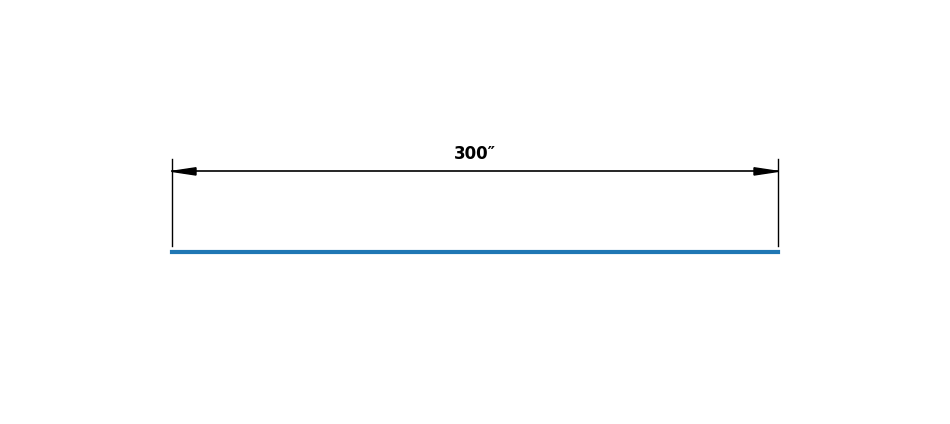

In [68]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Object edge
ax.plot([0, 300], [0, 0], lw=3)
# ax.plot([0, 0], [-20, 20], lw=3)
# ax.plot([300, 300], [-20, 20], lw=3)

# Dimension
add_aci_dimension(
    ax,
    (0, 0),
    (300, 0),
    obj_center=(150, 0),
    offset=40,
    inches=True
)

ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-80, 380)
ax.set_ylim(-80, 120)

plt.show()

In [62]:
import numpy as np

def compute_ibeam_points(B_top, t_top,
                         B_bot, t_bot,
                         t_web,
                         H):
    """
    Returns dictionary of all critical I-beam coordinates.
    """

    y0 = 0
    y1 = t_bot
    y2 = H - t_top
    y3 = H

    pts = {}

    # Bottom flange corners
    pts["BL"]  = (-B_bot/2, y0)
    pts["BR"]  = ( B_bot/2, y0)
    pts["BTL"] = (-B_bot/2, y1)
    pts["BTR"] = ( B_bot/2, y1)

    # Web junctions
    pts["WL"]  = (-t_web/2, y1)
    pts["WR"]  = ( t_web/2, y1)
    pts["WTL"] = (-t_web/2, y2)
    pts["WTR"] = ( t_web/2, y2)

    # Top flange corners
    pts["TTL"] = (-B_top/2, y2)
    pts["TTR"] = ( B_top/2, y2)
    pts["TL"]  = (-B_top/2, y3)
    pts["TR"]  = ( B_top/2, y3)

    return pts

In [63]:
from matplotlib.patches import Polygon

def draw_ibeam_section(ax, pts, lw=2):

    outline = [
        pts["BL"],
        pts["BR"],
        pts["BTR"],
        pts["WR"],
        pts["WTR"],
        pts["TTR"],
        pts["TR"],
        pts["TL"],
        pts["TTL"],
        pts["WTL"],
        pts["WL"],
        pts["BTL"],
    ]

    poly = Polygon(outline, closed=True,
                   fill=False, edgecolor="black", linewidth=lw)

    ax.add_patch(poly)

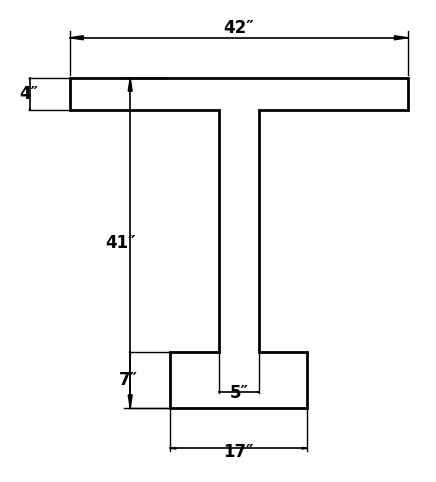

In [74]:
import matplotlib.pyplot as plt

# Parameters
B_top = 42
t_top = 4
B_bot = 17
t_bot = 7
t_web = 5
H = 41

fig, ax = plt.subplots(figsize=(12, 6))

# Compute geometry
pts = compute_ibeam_points(B_top, t_top,
                           B_bot, t_bot,
                           t_web,
                           H)

# Draw geometry
draw_ibeam_section(ax, pts)

obj_center = (0, H/2)

# --------------------------------------------------
# Dimensions (now trivial and clean)
# --------------------------------------------------

#Overall height
add_aci_dimension(ax, pts["BL"], pts["TL"], obj_center, offset=5, label="41″", alignment="vertical")

# Top flange width
add_aci_dimension(ax, pts["TL"], pts["TR"], obj_center, offset=5, label="42″")

# Bottom flange width
add_aci_dimension(ax, pts["BL"], pts["BR"], obj_center, offset=5, label="17″")

# Web thickness
add_aci_dimension(ax, pts["WL"], pts["WR"], obj_center, offset=5, label="5″")

# Top flange thickness
add_aci_dimension(ax, pts["TTL"], pts["TL"], obj_center, offset=5, label="4″")

# Bottom flange thickness
add_aci_dimension(ax, pts["BL"], pts["BTL"], obj_center, offset=5, label="7″")

# --------------------------------------------------

ax.set_aspect("equal")
ax.axis("off")
# ax.set_xlim(-60, 60)
# ax.set_ylim(-20, 70)

plt.show()

In [4]:
import numpy as np

def ibeam_section_properties(
    B_top, t_top,
    B_bot, t_bot,
    t_web,
    H
):
    """
    Returns:
        A      : Total area
        y_bar  : Centroid from bottom
        Ix     : Moment of inertia about strong axis
        Iy     : Moment of inertia about weak axis
    """

    # -----------------------------------------
    # Areas
    # -----------------------------------------
    A_bot = B_bot * t_bot
    A_web = t_web * (H - t_top - t_bot)
    A_top = B_top * t_top

    A_total = A_bot + A_web + A_top

    # -----------------------------------------
    # Centroid locations from bottom
    # -----------------------------------------
    y_bot = t_bot / 2
    y_web = t_bot + (H - t_top - t_bot) / 2
    y_top = H - t_top / 2

    # -----------------------------------------
    # Global centroid
    # -----------------------------------------
    y_bar = (
        A_bot * y_bot +
        A_web * y_web +
        A_top * y_top
    ) / A_total

    # -----------------------------------------
    # Local Moments of Inertia
    # -----------------------------------------
    Ix_bot_local = (B_bot * t_bot**3) / 12
    Ix_web_local = (t_web * (H - t_top - t_bot)**3) / 12
    Ix_top_local = (B_top * t_top**3) / 12

    Iy_bot = (t_bot * B_bot**3) / 12
    Iy_web = ((H - t_top - t_bot) * t_web**3) / 12
    Iy_top = (t_top * B_top**3) / 12

    # -----------------------------------------
    # Parallel Axis Theorem (Ix only)
    # -----------------------------------------
    Ix = (
        Ix_bot_local + A_bot * (y_bar - y_bot)**2 +
        Ix_web_local + A_web * (y_bar - y_web)**2 +
        Ix_top_local + A_top * (y_top - y_bar)**2
    )

    Iy = Iy_bot + Iy_web + Iy_top  # symmetric about vertical axis
    
    # -----------------------------------------
    # Section Modulus
    # -----------------------------------------
    S_top = Ix / (H - y_bar)
    S_bot = Ix / y_bar

    return {
        "A": A_total,
        "y_bar": y_bar,
        "Ix": Ix,
        "Iy": Iy,
        "S_top": S_top,
        "S_bot": S_bot
    }


In [5]:
props = ibeam_section_properties(
    B_top=30,
    t_top=4,
    B_bot=15,
    t_bot=8,
    t_web=5,
    H=42
)



for k, v in props.items():
    print(k, "=", v)

A = 390
y_bar = 22.384615384615383
Ix = 89902.30769230769
Iy = 11562.5
S_top = 4583.254901960784
S_bot = 4016.254295532646


In [1]:
def lerp(x, x0, x1, y0, y1):
    """
    Linear interpolation.

    Parameters
    ----------
    x  : target x
    x0 : first x
    x1 : second x
    y0 : value at x0
    y1 : value at x1

    Returns
    -------
    Interpolated y value at x
    """
    if x1 == x0:
        raise ValueError("x0 and x1 cannot be equal.")

    return y0 + (x - x0) * (y1 - y0) / (x1 - x0)

In [10]:
lerp(.63779, 4.407686+.63779, 0, 42, 0)

5.3091482349732715